*******************************************************************************************************************************************************************************************
 * Atharv Ravindra Sonawane
 * BE-B - 46
  
 * Problem statement : Linear regression by using Deep Neural network: Implement Boston housing price prediction problem by Linear regression using Deep Neural network. Use Boston House price prediction dataset.
 ****************************************************************************************************************************************************************************************

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import boston_housing
from sklearn.preprocessing import StandardScaler

In [ ]:
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))   # Output layer (linear regression)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 564.2834 - mae: 21.8850
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 493.8225 - mae: 20.2327
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 378.8835 - mae: 17.4135
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 209.5061 - mae: 12.3408
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 94.7040 - mae: 7.6339 
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 54.2382 - mae: 5.5475
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36.0537 - mae: 4.3966
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.6098 - mae: 3.7377
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24.1066 - mae: 3.5096
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 21.7155 - mae: 3.3216  
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20.5003 - mae: 3.1859 
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.6258 - mae: 3.1076 
Epoch 13/50
26/26 ━━━━━━

In [ ]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 20.2227 - mae: 2.9723
Test Loss (MSE): 20.22272300720215
Test MAE: 2.9722561836242676


In [ ]:
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [ ]:
print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: {y_test[i]:.2f}, Predicted: {predictions[i][0]:.2f}")


Sample Predictions:
Actual: 7.20, Predicted: 8.65
Actual: 18.80, Predicted: 17.58
Actual: 19.00, Predicted: 21.15
Actual: 27.00, Predicted: 34.88
Actual: 22.20, Predicted: 25.34


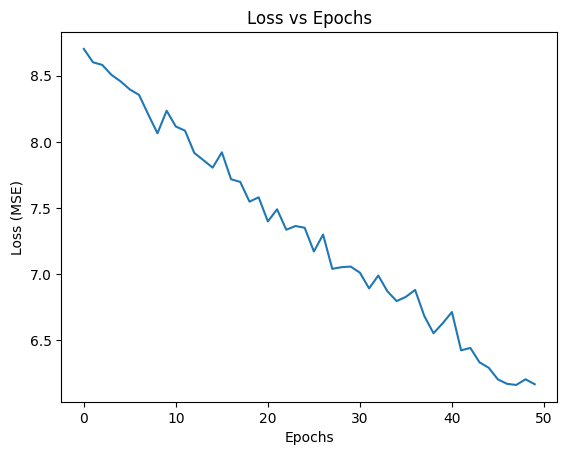

In [ ]:
import matplotlib.pyplot as plt

history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

plt.plot(history.history['loss'])
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


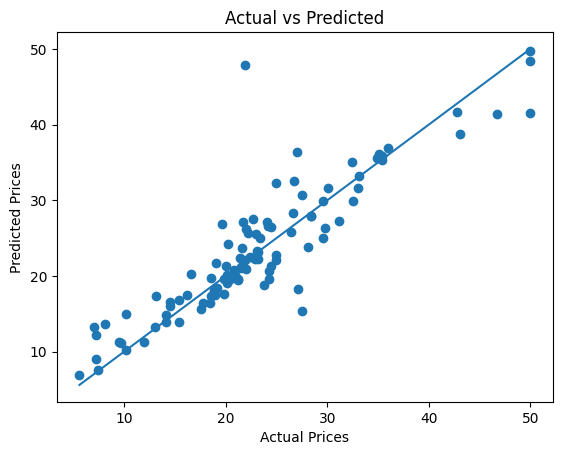

In [ ]:
predictions = model.predict(X_test)

plt.scatter(y_test, predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")

# Ideal line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])

plt.show()